# Model Evaluation Practice

* **load_digits**: Handwritten digit dataset (0–9) with 8×8 pixel images  
* Load the handwritten digit dataset and create a classification model using logistic regression.  
* Evaluate the created classification model:  
    * K-Fold Cross Validation  
    * Confusion Matrix  
    * Accuracy, Precision, Recall, etc.  
    * ROC, AUC  


In [ ]:
# from sklearn.pipeline import make_pipeline
# from sklearn.preprocessing import StandardScaler

In [20]:
from sklearn.datasets import load_digits

digits = load_digits()
X = digits.data
y = digits.target

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

### Problem 1

* Create a classification model using **RandomForestClassifier**.  

In [22]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=1)

### Problem 2

* Use **10-Fold cross validation** to evaluate the model created in Problem 1 based on accuracy.  
* Check the **average accuracy**.


In [23]:
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=10, shuffle=True, random_state=1)

# you must use a pipepline or a model which are not trained on the whole dataset
scores = cross_val_score(model, X, y, cv=kf, scoring="accuracy", n_jobs=2)

In [24]:
print(scores.round(3))
print(scores.mean())

[0.994 0.978 0.967 0.961 0.978 0.967 0.989 0.983 0.966 0.978]
0.9760707635009311


### Problem 3

* Print the **Confusion Matrix**.


In [25]:
from sklearn.metrics import confusion_matrix

model.fit(X_train, y_train)  # this should be done after kfold
y_pred = model.predict(X_test)
mat = confusion_matrix(y_test, y_pred)
mat

array([[57,  0,  0,  0,  2,  0,  0,  0,  0,  0],
       [ 0, 48,  0,  0,  0,  1,  0,  0,  0,  0],
       [ 0,  0, 49,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0, 61,  0,  0,  0,  0,  2,  1],
       [ 0,  0,  0,  0, 61,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0, 46,  0,  0,  0,  1],
       [ 0,  0,  0,  0,  0,  0, 51,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  0, 56,  0,  1],
       [ 0,  0,  0,  0,  0,  0,  0,  0, 45,  1],
       [ 0,  0,  0,  0,  0,  2,  0,  0,  0, 55]])

### Problem 4

* Print the **Accuracy**, **Precision**, **Recall**, and **F1 score** for the generated Logistic Regression model.  
* Use `classification_report`.


In [26]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.97      0.98        59
           1       1.00      0.98      0.99        49
           2       1.00      1.00      1.00        49
           3       1.00      0.95      0.98        64
           4       0.97      1.00      0.98        61
           5       0.94      0.98      0.96        47
           6       1.00      1.00      1.00        51
           7       1.00      0.98      0.99        57
           8       0.96      0.98      0.97        46
           9       0.93      0.96      0.95        57

    accuracy                           0.98       540
   macro avg       0.98      0.98      0.98       540
weighted avg       0.98      0.98      0.98       540



### Problem 5

* Use **`validation_curve`**.  
* Check how the model performance changes when varying the `n_estimators` value of `RandomForestClassifier`.  
* Draw a graph to compare the **accuracy** of the training dataset and the test dataset for visualization.


In [28]:
from sklearn.model_selection import validation_curve
import numpy as np

prange = np.arange(1, 100, 10)
train_scores, test_scores = validation_curve(
    model,
    X_train,
    y_train,
    param_name="n_estimators",
    param_range=prange,
    n_jobs=2,
    cv=3,
    scoring="accuracy",
)

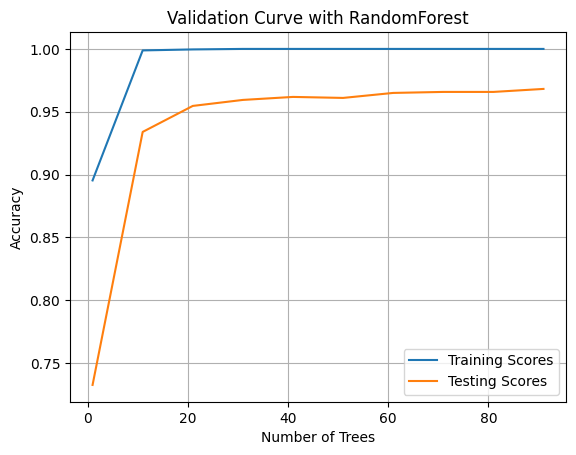

In [31]:
import matplotlib.pyplot as plt

train_means = np.mean(train_scores, axis=1)
test_means = np.mean(test_scores, axis=1)


plt.plot(prange, train_means, label="Training Scores")
plt.plot(prange, test_means, label="Testing Scores")
plt.title("Validation Curve with RandomForest")
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.legend(loc="best")
plt.grid()
plt.show()